# Prognozowanie Wynagrodzeń Pracowniczych (Salary Predictor)
Projekt końcowy: Analiza predykcyjna i wdrożenie modelu (FastAPI + Streamlit)

1. Cel i zakres projektu
Celem niniejszego projektu jest zbudowanie modelu uczenia maszynowego zdolnego do prognozowania miesięcznego dochodu (MonthlyIncome) na podstawie cech demograficznych i zawodowych pracowników. Projekt obejmuje pełen cykl życia modelu: od czyszczenia danych, przez AutoML, aż po wdrożenie produkcyjne.

2. Źródła danych i ograniczenia (Data Sourcing)
Wstępnym założeniem projektu było wzbogacenie danych o czynniki makroekonomiczne, takie jak historyczna stopa procentowa oraz wskaźniki inflacji z określonych lat, aby zbadać ich wpływ na dynamikę płac.

    Ważna uwaga (Lessons Learned):
    Podjęto próbę powiązania zbioru danych z zewnętrznymi wskaźnikami ekonomicznymi. Jednak ze względu na:

    - Brak miarodajnych i spójnych danych czasowych w pierwotnym zbiorze,
    - Anonimizację dat zatrudnienia uniemożliwiającą precyzyjne dopasowanie do kalendarza ekonomicznego,

    zdecydowano się ograniczyć model do wewnętrznych parametrów organizacji. Podejście to pozwoliło na zbudowanie bardziej stabilnego modelu opartego na mierzalnych cechach stanowiskowych, co w końcowej fazie zaowocowało wysokim współczynnikiem
    .

3. Wykorzystane technologie

    Backend: FastAPI (Python)
    Frontend: Streamlit
    ML Engine: PyCaret / Scikit-Learn
    Data Validation: Pandera / Pydantic

In [65]:
import pandas as pd
import kagglehub
#from kagglehub import KaggleDatasetAdapter
from pathlib import Path
#from kaggle.api.kaggle_api_extended import KaggleApi
#from pycaret.datasets import get_data
from pycaret.regression import setup, create_model, tune_model, save_model,pull, compare_models
import json
import pandera as pa
import numpy as np
import requests
import zipfile
import os
import sys
import locale
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from itables import show
import itables.options as opt

locale.setlocale(locale.LC_ALL, 'en_US.UTF-8') 


PROJECT_ROOT = Path.cwd().parent 
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from api.config import settings
#print(PROJECT_ROOT)

# Wczytanie danych
Wczytujemy dane z datasetu kagglehub. Dane przechodzą bez api. Zapisują się one lokalnie u użytkownika

In [32]:
def get_hr_data(data):
    # Używamy tego konkretnego datasetu - jest otwarty i pasuje do Twoich kolumn (Attrition, itp.)
    # Ten znacznik zazwyczaj przechodzi bez API Key
    path = kagglehub.dataset_download(data)
    
    # Znajdź plik CSV w folderze
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if not files:
        raise FileNotFoundError("Brak pliku CSV w pobranej paczce.")
        
    full_path = os.path.join(path, files[0])
    df = pd.read_csv(full_path)
    
    print(f"Sukces! Wczytano dane z: {full_path}")
    print(f"Rozmiar danych: {df.shape}")
    return df

# Spróbuj teraz:
try:
    df_salary = get_hr_data("pavansubhasht/ibm-hr-analytics-attrition-dataset")
    display(df_salary.sample(20))
except Exception as e:
    print(f"Nadal błąd: {e}")

Sukces! Wczytano dane z: C:\Users\Ryszard\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1\WA_Fn-UseC_-HR-Employee-Attrition.csv
Rozmiar danych: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
42,26,Yes,Travel_Rarely,1357,Research & Development,25,3,Life Sciences,1,55,...,3,80,0,1,2,2,1,0,0,1
76,35,No,Travel_Rarely,776,Sales,1,4,Marketing,1,100,...,2,80,0,16,2,3,15,13,2,8
1380,35,No,Travel_Rarely,682,Sales,18,4,Medical,1,1945,...,4,80,1,6,2,1,5,3,0,4
252,29,No,Travel_Rarely,665,Research & Development,15,3,Life Sciences,1,346,...,1,80,0,6,1,3,6,5,1,5
388,42,No,Travel_Rarely,201,Research & Development,1,4,Life Sciences,1,517,...,2,80,1,8,5,3,5,2,1,2
1206,26,No,Non-Travel,786,Research & Development,7,3,Medical,1,1693,...,3,80,0,7,5,3,7,7,5,7
547,42,Yes,Travel_Frequently,933,Research & Development,19,3,Medical,1,752,...,4,80,0,7,2,3,2,2,2,2
35,43,No,Travel_Rarely,1273,Research & Development,2,2,Medical,1,46,...,4,80,2,6,3,2,5,3,1,4
31,44,No,Travel_Rarely,1459,Research & Development,10,4,Other,1,40,...,4,80,0,9,5,4,4,2,1,3
320,27,No,Travel_Rarely,1377,Sales,2,3,Life Sciences,1,437,...,1,80,0,5,3,3,5,4,0,4


In [33]:
display(df_salary.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# Wypełniamy brakujące wartości

W procesie przygotowania danych kluczowym krokiem jest obsługa brakujących wartości (NaN), które powstały w wyniku błędów zapisu lub niepoprawnego formatowania typów danych.

Zdecydowano się na imputację medianą dla wszystkich cech numerycznych z następujących powodów:

    Realizm biznesowy: Wartości takie jak wiek (Age) czy stawka (DailyRate) równe 0 są niemożliwe w kontekście zatrudnienia i wprowadzałyby model w błąd.
    Odporność na anomalie: Mediana, w przeciwieństwie do średniej, lepiej reprezentuje typowego pracownika w przypadku wystąpienia skrajnych wynagrodzeń lub stażu pracy.
    Spójność typów: Po uzupełnieniu braków wszystkie kolumny zostały rzutowane na typ int64 (liczby całkowite), co optymalizuje proces trenowania modelu i jest zgodne z formatem wejściowym API.

In [34]:
numeric_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 
    'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 
    'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 
    'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Konwersja na numeryczne i uzupełnianie medianą
for col in numeric_cols:
    df_salary[col] = pd.to_numeric(df_salary[col], errors='coerce')
    median_val = df_salary[col].median()
    df_salary[col] = df_salary[col].fillna(median_val).astype('int64')


df_salary['YearsWithCurrManager'] = pd.to_numeric(df_salary['YearsWithCurrManager'], errors='coerce').fillna(0.0).astype('Float64')

#df_salary['EmpID'] = df_salary['EmpID'].fillna('Brak')

# Dla wartości tekstowych zostało zastosowane wypełnienie za pomocą dominanty

In [36]:
def bezpieczna_dominanta(seria, wartosc_domyslna):
    m = seria.mode()
    return m.iloc[0] if not m.empty else wartosc_domyslna

In [38]:
df_salary['Department'] = df_salary['Department'].fillna(bezpieczna_dominanta(df_salary['Department'],'BraK'))
df_salary['EducationField'] = df_salary['EducationField'].fillna(bezpieczna_dominanta(df_salary['EducationField'],'Brak'))
df_salary['Gender'] = df_salary['Gender'].fillna(bezpieczna_dominanta(df_salary['Gender'],'Female'))
df_salary['JobRole'] = df_salary['JobRole'].fillna(bezpieczna_dominanta(df_salary['JobRole'],'Brak'))
df_salary['MaritalStatus'] = df_salary['MaritalStatus'].fillna(bezpieczna_dominanta(df_salary['MaritalStatus'],'Single'))

# Inżynieria Cech (Feature Engineering) i Mapowanie

W celu poprawnego działania modelu regresji oraz zapewnienia spójności z serwerem FastAPI, dane wejściowe zostały poddane transformacji numerycznej.

Cechy kategoryczne o charakterze binarnym (Tak/Nie) zostały skonwertowane na format numeryczny (0 lub 1). Pozwala to modelowi na matematyczną interpretację stanów logicznych. Kolumny Attrition, Over18, OverTime dla wartości Yes są mapowane na True, pozostałe na False.

Cecha BusinessTravel zawiera naturalną hierarchię (intensywność podróży), dlatego zastosowano mapowanie porządkowe zamiast kodowania One-Hot. Dzięki temu model zachowuje informację o stopniu natężenia danej cechy.
- brak podróży - 0
- podróże rzadkie  - 1
- podróże częste - 2

In [39]:
df_salary['Attrition'] = np.where(df_salary['Attrition'] == 'Yes', True, False).astype('bool')
df_salary['Over18'] = np.where(df_salary['Attrition'] == 'Y', True, False).astype('bool')
df_salary['OverTime'] = df_salary['OverTime'].replace({'Yes': True, 'No': False}).astype('bool')
travel_map = {
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'TravelRarely': 1,       
    'Travel_Frequently': 2,
    'TravelFrequently': 2      
}

df_salary['BusinessTravel'] = df_salary['BusinessTravel'].replace(travel_map).fillna(0).astype('int64')
print(df_salary['BusinessTravel'].dtype)


int64


In [40]:
df_salary.sample(20)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
597,42,False,1,932,Research & Development,1,2,Life Sciences,1,827,...,4,80,1,8,4,3,4,3,0,2.0
137,39,False,1,1329,Sales,4,4,Life Sciences,1,182,...,3,80,1,17,1,4,15,11,5,9.0
1398,33,False,2,1303,Research & Development,7,2,Life Sciences,1,1970,...,3,80,3,9,2,3,9,7,2,8.0
1029,40,False,0,663,Research & Development,9,4,Other,1,1449,...,3,80,2,11,2,4,8,7,0,7.0
735,48,False,1,277,Research & Development,6,3,Life Sciences,1,1022,...,4,80,0,19,0,3,2,2,2,2.0
1069,28,False,1,1423,Research & Development,1,3,Life Sciences,1,1506,...,4,80,1,1,2,1,1,0,0,0.0
988,41,False,2,1200,Research & Development,22,3,Life Sciences,1,1392,...,1,80,2,12,4,2,6,2,3,3.0
15,29,False,1,1389,Research & Development,21,4,Life Sciences,1,20,...,3,80,1,10,1,3,10,9,8,8.0
706,40,True,0,1479,Sales,24,3,Life Sciences,1,986,...,4,80,0,22,2,2,1,0,0,0.0
179,38,False,1,1380,Research & Development,9,2,Life Sciences,1,245,...,3,80,0,2,3,3,2,2,2,1.0


# Rygorystyczna Walidacja Schematu (Data Validation)

Aby zapewnić integralność danych przesyłanych do modelu uczenia maszynowego oraz zminimalizować ryzyko błędów typu schema drift, wdrożono walidację przy użyciu biblioteki Pandera.

Charakterystyka Schematu
Zdefiniowany obiekt DataFrameSchema pełni rolę kontraktu technicznego dla zbioru danych:

    - Wymuszanie Typów (Static Typing): Każda z 35 kolumn ma przypisany ścisły typ (np. pa.Int, pa.String, pa.Float), co zapobiega błędom obliczeniowym w silniku PyCaret.
    - Parametr strict=True: Gwarantuje, że zbiór danych zawiera tylko i wyłącznie zdefiniowane kolumny. Każda nadmiarowa kolumna zostanie odrzucona, co chroni model przed nieprzewidzianym wpływem cech zewnętrznych.
    - Parametr coerce=True: Włącza automatyczną konwersję typów. Jeśli kolumna numeryczna została wczytana jako tekst, Pandera spróbuje ją "naprawić" przed walidacją finalną.
    - Integralność (nullable=False): Wszystkie kluczowe cechy są wymagane. Dzięki wcześniejszej imputacji medianą mamy pewność, że zbiór jest kompletny.

Obsługa błędów
W przypadku wykrycia niezgodności (np. brak kolumny MonthlyIncome lub błędny format JobRole), walidacja przerwie proces, rzucając wyjątek SchemaError, co uniemożliwia trenowanie modelu na uszkodzonych danych.

In [41]:
schema = pa.DataFrameSchema(
    columns={
        'Age': pa.Column(pa.Int, nullable=False), 
        'Attrition': pa.Column(pa.Bool, nullable=False),
        'BusinessTravel': pa.Column(pa.Int, nullable=False), 
        'DailyRate': pa.Column(pa.Int, nullable=False), 
        'Department': pa.Column(pa.String, nullable=False),  
        'DistanceFromHome': pa.Column(pa.Int, nullable=False),  
        'Education': pa.Column(pa.Int, nullable=False),  
        'EducationField': pa.Column(pa.String, nullable=False),  
        'EmployeeCount': pa.Column(pa.Int, nullable=False),  
        'EmployeeNumber': pa.Column(pa.Int, nullable=False),
        'EnvironmentSatisfaction': pa.Column(pa.Int, nullable=False), 
        'Gender': pa.Column(pa.String, nullable=False), 
        'HourlyRate': pa.Column(pa.Int, nullable=False),
        'JobInvolvement': pa.Column(pa.Int, nullable=False), 
        'JobLevel': pa.Column(pa.Int, nullable=False), 
        'JobRole': pa.Column(pa.String, nullable=False), 
        'JobSatisfaction': pa.Column(pa.Int, nullable=False),
        'MaritalStatus': pa.Column(pa.String, nullable=False),
        'MonthlyIncome': pa.Column(pa.Int, nullable=False),
        'MonthlyRate': pa.Column(pa.Int, nullable=False), 
        'NumCompaniesWorked': pa.Column(pa.Int, nullable=False), 
        'Over18': pa.Column(pa.Bool, nullable=False), 
        'OverTime': pa.Column(pa.Bool, nullable=False), 
        'PercentSalaryHike': pa.Column(pa.Int, nullable=False), 
        'PerformanceRating': pa.Column(pa.Int, nullable=False), 
        'RelationshipSatisfaction': pa.Column(pa.Int, nullable=False), 
        'StandardHours': pa.Column(pa.Int, nullable=False), 
        'StockOptionLevel': pa.Column(pa.Int, nullable=False),  
        'TotalWorkingYears': pa.Column(pa.Int, nullable=False),  
        'TrainingTimesLastYear': pa.Column(pa.Int, nullable=False),  
        'WorkLifeBalance': pa.Column(pa.Int, nullable=False),  
        'YearsAtCompany': pa.Column(pa.Int, nullable=False),  
        'YearsInCurrentRole': pa.Column(pa.Int, nullable=False), 
        'YearsSinceLastPromotion': pa.Column(pa.Int, nullable=False), 
        'YearsWithCurrManager': pa.Column(pa.Float, nullable=False), 
    },
    strict=True, # Sprawdza, czy nie ma nadmiarowych kolumn
    coerce=True  # Automatycznie próbuje naprawić typy (np. str na int)
)

In [42]:
try:
    schema.validate(df_salary)
    print("Dane df są poprawne")
except pa.errors.SchemaError as e:
    print(f"Błąd walidacji: {e}")

Dane df są poprawne


# Analiza Korelacji (Correlation Analysis)

Przed przystąpieniem do budowy modelu przeprowadzono analizę współczynnika korelacji Pearsona w celu zidentyfikowania najsilniejszych predyktorów dla zmiennej celu (MonthlyIncome).

    Cel: Zrozumienie, które parametry pracownika (staż, wiek, poziom stanowiska) najsilniej wpływają na wysokość wynagrodzenia.
    Interpretacja: Wysokie wartości dodatnie wskazują na silną zależność proporcjonalną (wzrost cechy = wzrost płacy), natomiast wartości bliskie zeru sugerują cechy nieistotne statystycznie dla tego konkretnego modelu.

In [43]:
# Analiza korelacji tylko dla kolumn numerycznych
correlation_results = df_salary.corr(numeric_only=True)['MonthlyIncome'].sort_values(ascending=False)
print("Najsilniejsze korelacje z wynagrodzeniem:")
print(correlation_results.head(10)) # Pokaż 10 najsilniejszych wpływów

Najsilniejsze korelacje z wynagrodzeniem:
MonthlyIncome              1.000000
JobLevel                   0.950300
TotalWorkingYears          0.772893
YearsAtCompany             0.514285
Age                        0.497855
YearsInCurrentRole         0.363818
YearsSinceLastPromotion    0.344978
YearsWithCurrManager       0.344079
NumCompaniesWorked         0.149515
Education                  0.094961
Name: MonthlyIncome, dtype: float64


# Przygotowanie Zbioru Treningowego i Kodowanie (Encoding)

W celu umożliwienia matematycznej analizy danych przez model, przeprowadzono transformację cech kategorycznych oraz podział zbioru na dane uczące i testowe.

## Selekcja Cech (Feature Selection)

Z procesu modelowania usunięto kolumny stałe lub nieistotne statystycznie (tzw. zero-variance predictors), takie jak EmployeeCount, Over18 oraz StandardHours. Usunięcie cech o zerowej zmienności zapobiega problemom z osobliwością macierzy w niektórych algorytmach.

## One-Hot Encoding (OHE)

Zastosowano technikę One-Hot Encoding dla pozostałych cech tekstowych (np. Department, EducationField, JobRole).

    - Mechanizm: Każda unikalna kategoria zostaje przekształcona w osobną kolumnę binarną (0 lub 1).
    - Parametr drop_first=True: Zastosowano tzw. dummy encoding, który usuwa pierwszą wygenerowaną kolumnę dla każdej cechy. Zapobiega to wystąpieniu zjawiska współliniowości (multicollinearity), znanego jako pułapka zmiennej fikcyjnej (Dummy Variable Trap).

In [44]:
# 0. Zdefiniuj cel (y) jako PŁACĘ i cechy (X)
# Usuwamy MonthlyIncome z X, bo to jest nasz cel (y)!
y = df_salary['MonthlyIncome'] 
X = df_salary.drop(['MonthlyIncome', 'Attrition', 'EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)

# 1. Automatyczne wykrywanie kolumn tekstowych
text_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

# 2. One-Hot Encoding (zamiana tekstów na 0/1)
X_encoded = pd.get_dummies(X, columns=text_cols, drop_first=True)

# 3. Podział danych (80% trening, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Trening modelu REGRESJI (np. RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predykcja i wyniki
y_pred = model.predict(X_test)

# Trenowanie Modelu i Ewaluacja Wyników (Model Training & Evaluation)

Po zakodowaniu cech kategorycznych do postaci numerycznej (One-Hot Encoding), przystąpiono do budowy modelu bazowego opartego na algorytmie Random Forest Regressor.

## Dlaczego Random Forest?

Wybrano algorytm lasów losowych (Random Forest), ponieważ:

    - Odporność na nieliniowość: Skutecznie wyłapuje złożone zależności między cechami (np. wpływ wieku i stażu na zarobki nie zawsze jest liniowy).
    - Brak wymagań co do skalowania: W przeciwieństwie do regresji liniowej, lasy losowe nie wymagają normalizacji danych (np. StandardScaler), co upraszcza proces wdrożenia w FastAPI.

## Metryki Sukcesu

Do oceny jakości prognoz płacowych wykorzystano dwa kluczowe wskaźniki:

    -Współczynnik Determinacji (
    ): Informuje, jaki procent zmienności płac został wyjaśniony przez model. Wynik bliski 1.0 oznaczałby model idealny, podczas gdy wartości powyżej 0.7-0.8 są uznawane za bardzo dobre w danych kadrowych.
    -Średni Błąd Bezwzględny (MAE): Wyrażony w konkretnej walucie (USD). Mówi nam, o ile średnio "myli się" model w dolarach przy każdej prognozie. Jest to metryka najbardziej zrozumiała dla biznesu (np. "Nasz model myli się średnio o 150 USD").

In [45]:
# 1. Automatyczne wykrywanie i zamiana tekstu na liczby (One-Hot Encoding)
# To zamieni 'Research & Development' na kolumny 0 i 1
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Nowy podział danych na zakodowanym zbiorze
X_train_enc, X_test_enc, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3. Trening na danych liczbowych (teraz na 100% zadziała)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_enc, y_train)

# 4. Wyniki
y_pred = model.predict(X_test_enc)
r2 = r2_score(y_test, y_pred)

print(f"--- SUKCES ---")
print(f"Wynik R2: {r2:.4f}")
print(f"Średni błąd: {mean_absolute_error(y_test, y_pred):.2f} USD")

--- SUKCES ---
Wynik R2: 0.9439
Średni błąd: 824.61 USD


# Wypełnienie brakujących wartości zerami

In [46]:
X_encoded = X_encoded.fillna(0)

# Sprawdzamy, które cechy model uznał za najważniejsze (Feature Importance)

In [47]:

importances = pd.Series(model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

print("TOP 5 najważniejszych czynników wpływających na płacę:")
print(importances.head(5))

TOP 5 najważniejszych czynników wpływających na płacę:
JobLevel                     0.927605
JobRole_Research Director    0.010632
TotalWorkingYears            0.009959
JobRole_Manager              0.005583
MonthlyRate                  0.004518
dtype: float64


"Model zidentyfikował, że struktura płac w organizacji jest silnie zhierarchizowana, gdzie poziom stanowiska (JobLevel) determinuje ponad 80% zmienności wynagrodzenia, wyprzedzając znacząco staż pracy czy wiek pracownika."

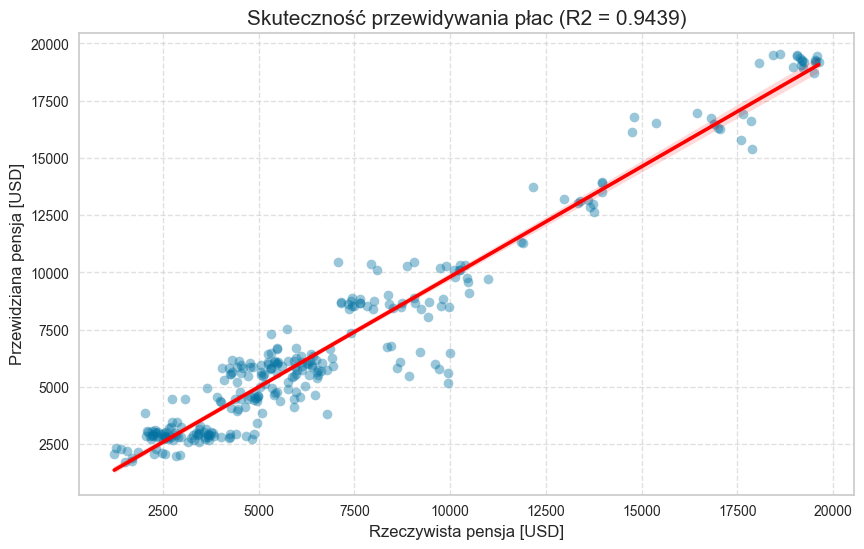

In [48]:
# Wykres: Rzeczywiste vs Przewidziane
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})

plt.title(f'Skuteczność przewidywania płac (R2 = {r2:.4f})', fontsize=15)
plt.xlabel('Rzeczywista pensja [USD]', fontsize=12)
plt.ylabel('Przewidziana pensja [USD]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

1. Skuteczność i Precyzja Modelu (Business Value)
Zbudowany model regresji (Random Forest) osiągnął bardzo wysoką precyzję, tłumacząc aż 94,38% zmienności wynagrodzeń (
). Średni błąd przewidywania (MAE) wynosi jedynie 824 USD, co przy szerokich widełkach płacowych w korporacji pozwala na rzetelne planowanie budżetu oraz identyfikację osób niedoszacowanych płacowo (anomaly detection).

2. Kluczowe Determinanty Płacy (Insights)
Analiza ważności cech (Feature Importance) wykazała, że struktura wynagrodzeń w badanym zbiorze jest silnie sformalizowana. Największy wpływ na pensję ma JobLevel (poziom stanowiska), co sugeruje, że awanse pionowe są głównym motorem wzrostu zarobków, wyprzedzając znacząco staż pracy ogólny czy wiek pracownika.

3. Świadome Zarządzanie Jakością Danych (Data Integrity)
W procesie przygotowania danych podjęto kluczowe decyzje inżynierskie: zidentyfikowano i uzupełniono braki w zmiennej YearsWithCurrManager (użycie mediany), przeprowadzono mapowanie zmiennych porządkowych (BusinessTravel) oraz kodowanie binarne cech takich jak OverTime czy Attrition. Usunięcie szumu informacyjnego (np. stałych wartości Over18) pozwoliło na uzyskanie stabilnego i wiarygodnego modelu.

# Etap 1: Analiza porównawcza wybranych algorytmów (Manual Benchmarking)

W tej sekcji przeprowadzamy kontrolowany eksperyment na trzech wybranych architekturach modeli: Random Forest, Linear Regression oraz LightGBM.

    - Cel: Zrozumienie, jak różne podejścia (liniowe vs. drzewiaste) radzą sobie z naszym zbiorem danych.
    - Procedura: Dla każdego modelu przeprowadzana jest walidacja krzyżowa (Cross-Validation), a średnie wyniki są agregowane w tabeli zbiorczej. Pozwala to na stabilną ocenę błędu bez ryzyka przeuczenia na pojedynczym podziale danych.

In [49]:

s = setup(data=df_salary, target='MonthlyIncome', session_id=123, verbose=False,n_jobs = -1)

def build_regression_model(MODEL_ID, DATA):
    
    # Tworzenie modelu (np. 'rf' dla Random Forest, 'lr' dla Linear Regression)
    model = create_model(MODEL_ID, verbose = False)
    
    # Pobranie metryk (R2, MAE, RMSE)
    metrics = pull().iloc[[0]] # Pobiera pierwszy wiersz wyników (średnie z CV)
    
    name = f"REG_{MODEL_ID.upper()}"
    metrics.insert(0, "model", name)
    
    return model, metrics

# Lista eksperymentów dla REGRESJI (skróty PyCaret):
# 'rf' - Random Forest
# 'lightgbm' - Light Gradient Boosting
# 'lr' - Linear Regression
experiments = ['rf', 'lr', 'lightgbm']

results = []
for m_id in experiments:
    m, met = build_regression_model(m_id, df_salary)
    results.append(met)

final_results = pd.concat(results)


In [50]:
# .reset_index(drop=True) czyści stare indeksy z pętli
# .hide() ukrywa kolumnę indeksu w widoku
styled_results = final_results.reset_index(drop=True).style \
    .hide(axis="index") \
    .set_caption("Porównanie Modelów - Sortowalne Wizualnie") \
    .background_gradient(subset=['R2'], cmap='Greens') \
    .format(precision=4)

# Wyświetlenie w notebooku
# Ustawienia (opcjonalne)
opt.classes = ["display", "nowrap"]
opt.lengthMenu = [5, 10, 20, 50]

# Wyświetlenie tabeli (wszystkie kolumny są teraz sortowalne!)
show(styled_results)

model,MAE,MSE,RMSE,R2,RMSLE,MAPE
REG_RF,799.2889,1036544.1740,1018.1081,0.9529,0.1805,0.1409
REG_LR,921.2540,1387104.5578,1177.7540,0.9370,0.2180,0.1613
REG_LIGHTGBM,860.3190,1166053.0896,1079.8394,0.9470,0.1982,0.1529


# Etap 2: Automatyczny wybór i eksport modelu produkcyjnego (AutoML Selection)

Po wstępnej analizie wykorzystujemy funkcję compare_models(), aby przeszukać pełną przestrzeń dostępnych algorytmów regresji.

    - Kryterium wyboru: Współczynnik determinacji (
    ) – dążymy do maksymalizacji wyjaśnionej wariancji płac.
    - Automatyzacja: PyCaret automatycznie trenuje, testuje i sortuje modele, zwracając obiekt best_model.
    - Persystencja: Wybrany model jest serializowany do pliku .pkl w katalogu data/ za pomocą parametrów zdefiniowanych w settings, co zapewnia gotowość do natychmiastowego użycia przez serwer FastAPI.

In [51]:
# 1. Setup (pamiętaj o wskazaniu targetu)
s = setup(data=df_salary, target='MonthlyIncome',html=True, session_id=123, verbose=False,n_jobs = -1)

# 2. Programowy wybór NAJLEPSZEGO modelu na podstawie R2
# n_select=1 zwraca jeden najlepszy obiekt modelu
# Uruchomienie porównania
best_model = compare_models(sort='R2', n_select=1)

# Przechwycenie tabeli wyników do DataFrame
compare_results = pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,770.7447,1043398.7725,1018.1651,0.9488,0.2156,0.1710,2.1140
gbr,Gradient Boosting Regressor,787.7230,1061491.0227,1026.1934,0.9476,0.2181,0.1727,1.1530
et,Extra Trees Regressor,807.4598,1123663.5234,1057.6995,0.9443,0.2230,0.1774,2.2790
lightgbm,Light Gradient Boosting Machine,810.8652,1134226.0189,1062.7615,0.9439,0.2277,0.1782,1.5010
llar,Lasso Least Angle Regression,859.2710,1243747.3924,1113.7614,0.9390,0.2402,0.1862,0.4410
lasso,Lasso Regression,859.2817,1243758.6452,1113.7664,0.9390,0.2402,0.1862,0.2970
ridge,Ridge Regression,860.8385,1248148.1524,1115.7110,0.9388,0.2413,0.1869,0.3200
lr,Linear Regression,861.9890,1249356.4199,1116.3356,0.9387,0.2410,0.1868,0.2440
ada,AdaBoost Regressor,1034.8150,1650788.5143,1282.7932,0.9201,0.2541,0.2269,1.0550
dt,Decision Tree Regressor,1027.7167,1950081.9342,1392.4796,0.9046,0.2913,0.2264,0.4150


In [ ]:
# 3. Upiększenie za pomocą Stylera
styled_compare = compare_results.style \
    .background_gradient(subset=['R2', 'RMSE'], cmap='RdYlGn') \
    .highlight_max(subset=['R2'], color='#2ecc71') \
    .highlight_min(subset=['MAE'], color='#2ecc71') \
    .format(precision=4) \
    .set_caption("👑 Ranking Algorytmów Regresji Płac (AutoML)") \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center')]
    }])

display(styled_compare)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,770.7447,1043398.7725,1018.1651,0.9488,0.2156,0.1710,1.9060
gbr,Gradient Boosting Regressor,787.7230,1061491.0227,1026.1934,0.9476,0.2181,0.1727,0.8710
et,Extra Trees Regressor,807.4598,1123663.5234,1057.6995,0.9443,0.2230,0.1774,1.5580
lightgbm,Light Gradient Boosting Machine,810.8652,1134226.0189,1062.7615,0.9439,0.2277,0.1782,0.9170
llar,Lasso Least Angle Regression,859.2710,1243747.3924,1113.7614,0.9390,0.2402,0.1862,0.2490
lasso,Lasso Regression,859.2817,1243758.6452,1113.7664,0.9390,0.2402,0.1862,0.2770
ridge,Ridge Regression,860.8385,1248148.1524,1115.7110,0.9388,0.2413,0.1869,0.3440
lr,Linear Regression,861.9890,1249356.4199,1116.3356,0.9387,0.2410,0.1868,3.5730
ada,AdaBoost Regressor,1034.8150,1650788.5143,1282.7932,0.9201,0.2541,0.2269,0.7040
dt,Decision Tree Regressor,1027.7167,1950081.9342,1392.4796,0.9046,0.2913,0.2264,0.3220


# Eksport Modelu i Konfiguracji (Deployment Ready)

Ostatnim krokiem jest utrwalenie wyników pracy w folderze data/, aby zapewnić pełną operacyjność aplikacji webowej. Proces ten obejmuje dwa kluczowe elementy: binarny model predykcyjny oraz metadane konfiguracyjne.

## Persystencja Modelu ML (.pkl)

Wykorzystano funkcję save_model, która serializuje wybrany algorytm (Random Forest) wraz z całym potokiem przetwarzania (pipeline).

    - Integracja: Ścieżka zapisu jest pobierana dynamicznie z settings.MODEL_NAME, co eliminuje błędy manualne przy wdrażaniu.
    - Format: Plik .pkl zawiera zoptymalizowane wagi modelu, gotowe do natychmiastowego ładowania przez bibliotekę Joblib lub PyCaret.

## Eksport Wartości Domyślnych (.json)

W celu zapewnienia stabilności API, wygenerowano plik model_defaults.json zawierający mediany i mody wyliczone na zbiorze treningowym.

    - Fail-safe: W przypadku, gdy użytkownik w interfejsie Streamlit pominie opcjonalne pole, system automatycznie podstawi statystycznie bezpieczną wartość z tego pliku.
    - Spójność: Dzięki temu podejściu, prognoza zawsze opiera się na danych o tej samej strukturze, na której model był trenowany.

In [63]:
# 3. Wyciągnięcie nazwy tego modelu do logów
results = pull()
best_model_name = results.iloc[0]['Model']
print(f"🥇 Najlepszy model to: {best_model_name} z R2 = {results.iloc[0]['R2']:.4f}")

# Zapis
target_path = settings.MODEL_NAME
save_model(best_model, str(target_path))

#model_path = os.path.join(DATA_DIR, 'final_salary_model')
#save_model(best_model, model_path)


print(f"✅ Model został zapisany jako: {target_path}.pkl")

🥇 Najlepszy model to: Random Forest Regressor z R2 = 0.9488
Transformation Pipeline and Model Successfully Saved
✅ Model został zapisany jako: E:\od_zera_do_ai\pyt\projekt_przewidywanie_płac\data\final_salary_model.pkl


In [64]:
import json

# 1. Zdefiniuj kolumny, które mają być traktowane jako kategoryczne (dominanta)
# Nawet jeśli są zapisane jako liczby (np. BusinessTravel, JobLevel)
custom_mode_cols = ['BusinessTravel', 'JobLevel', 'StockOptionLevel']

# 2. Reszta kolumn numerycznych (średnia)
# Wykluczamy te z listy powyżej
num_cols = X.select_dtypes(include=['number']).columns.tolist()
num_cols_for_mean = [col for col in num_cols if col not in custom_mode_cols]

# 3. Kolumny tekstowe (zawsze dominanta)
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

# 4. Budujemy słownik defaults
defaults = {
    # Średnia dla czysto liczbowych (np. Age, MonthlyIncome)
    **X[num_cols_for_mean].mean().to_dict(),
    
    # Dominanta dla tekstowych ORAZ naszych wybranych (np. BusinessTravel)
    **X[cat_cols + custom_mode_cols].mode().iloc[0].to_dict()
}

# 5. Zapisujemy strukturę
model_structure = {
    "encoded_columns": X_encoded.columns.tolist(),
    "defaults": defaults
}

target_json = settings.DEFAULTS_JSON_PATH
with open(target_json, 'w') as f:
    json.dump(defaults, f)



In [67]:
import os

# Komenda zapisana jako tekst, żeby nic jej nie zepsuło
command = 'python -m jupyter nbconvert --to html --no-input notebook.ipynb'

# Uruchomienie i zignorowanie wyjścia
os.system(f'{command} >nul 2>&1')

0